Implementation of:-
- my pipeline of data cleaning
- self made NN

In [38]:
#imports 
import sys
import os

parent_dir = os.path.abspath("../..")

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Data_Pipeline.cleaning import SimpleImputer
from Data_Pipeline.scaling import StandardScaler
from Data_Pipeline.split import train_test_split
from sklearn.metrics import confusion_matrix

In [39]:
#loading dataset
df = pd.read_csv(
    "data/covertype.csv"
)

print(df.head())
print(df.shape)
print(df)

   Cover_Type  Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0           5       2596      51      3                               258   
1           5       2590      56      2                               212   
2           2       2804     139      9                               268   
3           2       2785     155     18                               242   
4           5       2595      45      2                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   
3                             118                             3090   
4                              -1                              391   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  ...  Soil_Type34  \
0            221             232            148

In [40]:
#splitting dataset into features and target var
X_raw = df.iloc[:, :-1].values.astype(float)

y_raw = df.iloc[:, -1].astype(int).values

# Automatically handle label indexing
if y_raw.min() == 1:
    y_raw = y_raw - 1

print("Classes:", np.unique(y_raw))


Classes: [0 1]


In [41]:
#injection of missing values, cleaning and scaling
missing_indices = np.random.choice(
    X_raw.size,
    int(0.01 * X_raw.size),
    replace=False
)
X_raw.flat[missing_indices] = np.nan

imputer = SimpleImputer(
    strategy="mean"
)
X_clean = imputer.fit_transform(X_raw)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_clean)

In [42]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_raw,
    test_size=0.2,
    random_state=42
)

#one hot encoding of target var
num_classes = 7
y_train_onehot = np.eye(num_classes)[y_train]
y_test_onehot = np.eye(num_classes)[y_test]

In [43]:
#initialization of neural network parameters
input_size = X_train.shape[1]
hidden_size_1 = 64
hidden_size_2 = 32
output_size = 7

W1 = np.random.randn(
    input_size,
    hidden_size_1
) * np.sqrt(2/input_size)

b1 = np.zeros((1, hidden_size_1))

W2 = np.random.randn(
    hidden_size_1,
    hidden_size_2
) * np.sqrt(2/hidden_size_1)

b2 = np.zeros((1, hidden_size_2))

W3 = np.random.randn(
    hidden_size_2,
    output_size
) * np.sqrt(2/hidden_size_2)

b3 = np.zeros((1, output_size))

In [44]:
#activation functions 
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    exp_x = np.exp(
        x - np.max(x, axis=1, keepdims=True)
    )
    return exp_x / np.sum(
        exp_x,
        axis=1,
        keepdims=True
    )

In [45]:
# FWD pass
def forward(X):
    cache = {}
    cache['Z1'] = X @ W1 + b1
    cache['A1'] = relu(cache['Z1'])
    
    cache['Z2'] = cache['A1'] @ W2 + b2
    cache['A2'] = relu(cache['Z2'])
    
    cache['Z3'] = cache['A2'] @ W3 + b3
    cache['A3'] = softmax(cache['Z3'])
    return cache['A3'], cache

# loss function
def compute_loss(y_true, y_pred):
    epsilon = 1e-8
    # Average sample row loss across the batch array
    loss = -np.mean(np.sum(y_true * np.log(y_pred + epsilon), axis=1))
    return loss

# bwd pass 
def backward(X, y, y_pred, cache, lr=0.01):
    global W1, b1, W2, b2, W3, b3
    m = X.shape[0]  # Get exact row length of current batch instance

    # Layer 3 Gradients (Output Terminal)
    dZ3 = y_pred - y
    dW3 = (cache['A2'].T @ dZ3) / m
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m

    # Layer 2 Gradients (Hidden 2)
    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * relu_derivative(cache['Z2'])
    dW2 = (cache['A1'].T @ dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # Layer 1 Gradients (Hidden 1)
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(cache['Z1'])
    dW1 = (X.T @ dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    # Parametic Optimization Updates
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
    W3 -= lr * dW3
    b3 -= lr * db3

In [47]:
# training loop
losses = []
accuracies = []
epochs = 500
batch_size = 2048  # Keeps execution localized inside your hardware cache
m_total = X_train.shape[0]

for epoch in range(epochs):
    # Shuffle entire dataset at the beginning of each epoch
    permutation = np.random.permutation(m_total)
    X_train_shuffled = X_train[permutation]
    y_train_shuffled_oh = y_train_onehot[permutation]
    
    epoch_loss = 0
    
    # Process through localized mini-batches
    for i in range(0, m_total, batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        y_batch_oh = y_train_shuffled_oh[i:i+batch_size]
        
        # Forward pass on block slice
        y_pred_batch, cache = forward(X_batch)
        
        # Calculate loss tracking components
        loss = compute_loss(y_batch_oh, y_pred_batch)
        epoch_loss += loss * (X_batch.shape[0] / m_total)
        
        # Run local optimization adjustments (Using effective learning rate = 0.01)
        backward(X_batch, y_batch_oh, y_pred_batch, cache, lr=0.01)
        
    losses.append(epoch_loss)
    
    # Print status checks every 50 epochs to track speed and performance
    if epoch % 50 == 0 or epoch == epochs - 1:
        y_pred_all, _ = forward(X_train)
        predictions = np.argmax(y_pred_all, axis=1)
        accuracy = np.mean(predictions == y_train)
        accuracies.append(accuracy)
        print(f"Epoch {epoch:3d} | Loss: {epoch_loss:.4f} | Accuracy: {accuracy:.4f}")

Epoch   0 | Loss: 0.2238 | Accuracy: 0.9848
Epoch  50 | Loss: 0.0050 | Accuracy: 0.9984
Epoch 100 | Loss: 0.0041 | Accuracy: 0.9986
Epoch 150 | Loss: 0.0037 | Accuracy: 0.9987
Epoch 200 | Loss: 0.0035 | Accuracy: 0.9988
Epoch 250 | Loss: 0.0034 | Accuracy: 0.9988
Epoch 300 | Loss: 0.0032 | Accuracy: 0.9989
Epoch 350 | Loss: 0.0031 | Accuracy: 0.9989
Epoch 400 | Loss: 0.0031 | Accuracy: 0.9989
Epoch 450 | Loss: 0.0030 | Accuracy: 0.9990
Epoch 499 | Loss: 0.0029 | Accuracy: 0.9990


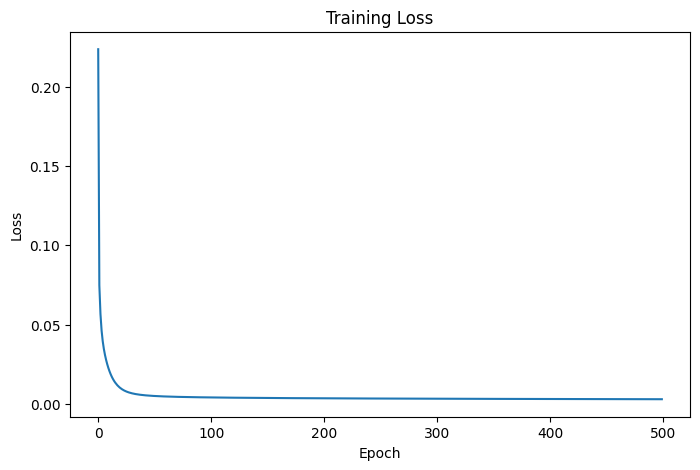

In [48]:
#loss curve 
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Test Accuracy: 0.9989242962746229


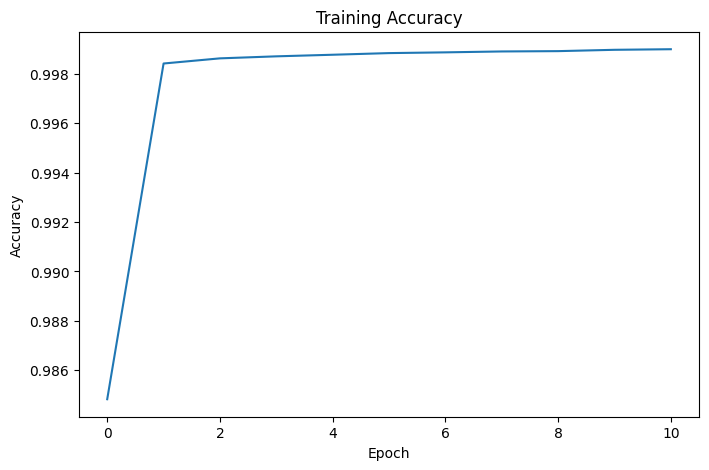

In [50]:
#accuracy 
test_probs, _ = forward(X_test)

test_predictions = np.argmax(
    test_probs,
    axis=1
)

test_accuracy = np.mean(
    test_predictions == y_test
)
print("Test Accuracy:", test_accuracy)

# Plotting the training accuracy history
plt.figure(figsize=(8,5))
plt.plot(accuracies)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

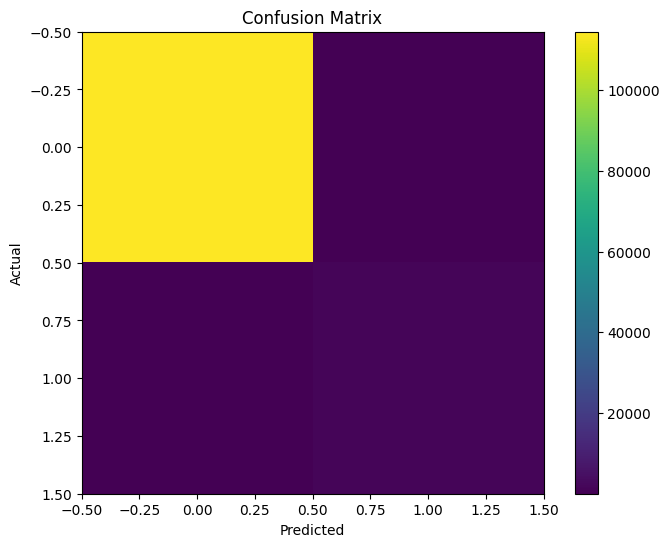

In [51]:
#confusion matrix
cm = confusion_matrix(
    y_test,
    test_predictions
)
plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0


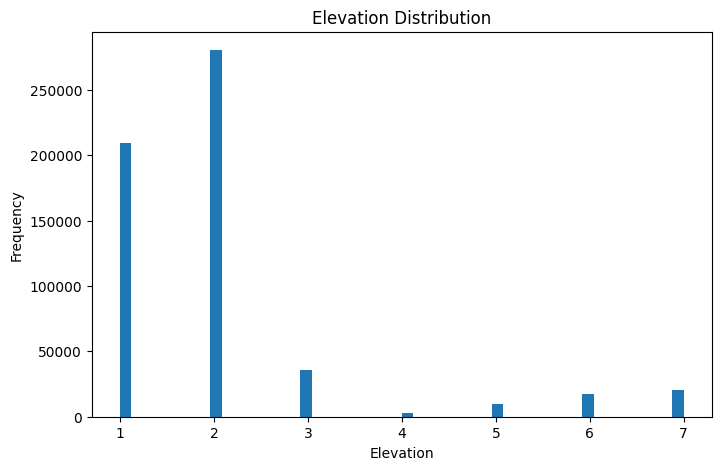

In [52]:
#prediciton vs actuals 
for i in range(10):

    print(
        f"Actual: {y_test[i]} | "
        f"Predicted: {test_predictions[i]}"
    )


#feature distribution visualization
plt.figure(figsize=(8,5))
plt.hist(
    X_raw[:,0],
    bins=50
)
plt.title("Elevation Distribution")
plt.xlabel("Elevation")
plt.ylabel("Frequency")
plt.show()